# Why $\cos(2\pi f t - kz)$ travels toward $+z$ and $\cos(2\pi f t + kz)$ toward $-z$

A travelling wave is a function of both position $z$ and time $t$:

$$ s_+(z, t) = \cos(2\pi f t - k z), \qquad s_-(z, t) = \cos(2\pi f t + k z), \qquad k = \frac{2\pi}{\lambda} $$

$f$ is the frequency (cycles per second) and $k$ the *wavenumber* (radians per metre): $2\pi f$ says how fast the phase changes in time, $k$ how fast it changes in space. The only difference between the two waves is the sign in front of $kz$, and that sign decides the direction of travel. This notebook shows why in four ways:

1. Take snapshots at successive times and watch a crest move
2. Follow one crest algebraically: the phase-velocity argument
3. Plot the wave in the $(z, t)$ plane — the slope of the stripes is the direction
4. The same thing in phasor form, which is how the array sees it

Numbers are chosen for a picture, not for BLE: $f = 1$ Hz, $\lambda = 1$ m, so $c = f\lambda = 1$ m/s. Nothing depends on the values.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

f   = 1.0            # Hz
lam = 1.0            # m
k   = 2*np.pi/lam    # rad/m
c   = f*lam          # m/s   phase velocity

def s_plus(z, t):  return np.cos(2*np.pi*f*t - k*z)
def s_minus(z, t): return np.cos(2*np.pi*f*t + k*z)

z = np.linspace(0, 3, 601)

## 1. Snapshots: watch a crest move

Freeze time at $t = 0$, then a little later, then later again. In each frame, mark the crest that was at $z = 0$ at $t = 0$.

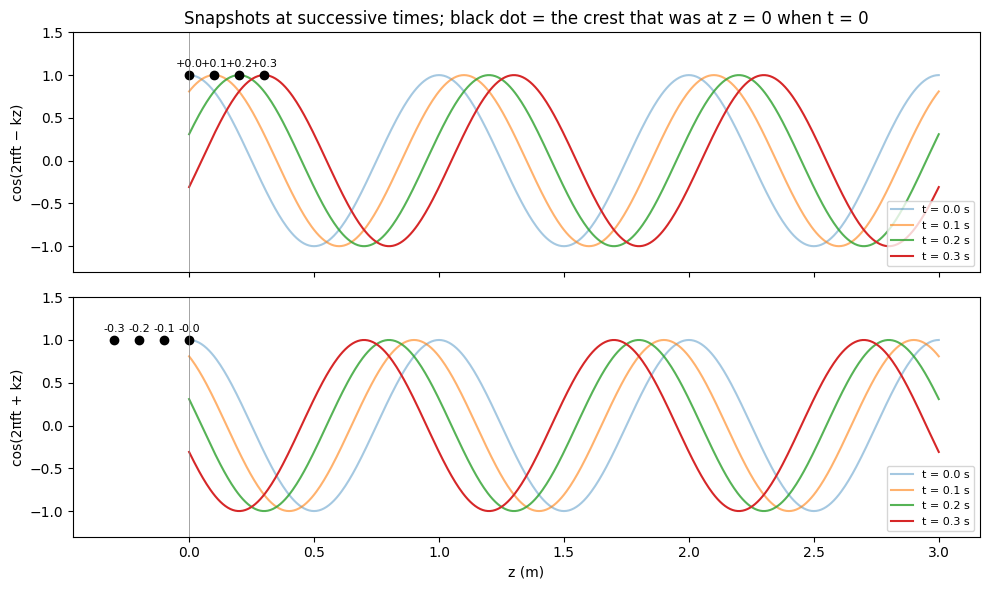

In [2]:
times = [0.0, 0.1, 0.2, 0.3]
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for i, (name, fn, sign) in enumerate([('cos(2πft − kz)', s_plus, +1), ('cos(2πft + kz)', s_minus, -1)]):
    for t in times:
        ax[i].plot(z, fn(z, t), label=f't = {t:.1f} s', alpha=0.4 + 0.6*t/max(times))
        zc = sign*c*t                                # where the tracked crest is now (derived in section 2)
        ax[i].plot(zc, 1.0, 'o', color='k', ms=6)
        ax[i].annotate(f'{zc:+.1f}', (zc, 1.0), textcoords='offset points', xytext=(0, 6), ha='center', fontsize=8)
    ax[i].set_ylabel(name); ax[i].axvline(0, color='gray', lw=0.5); ax[i].set_ylim(-1.3, 1.5); ax[i].legend(loc='lower right', fontsize=8)
ax[1].set_xlabel('z (m)'); ax[0].set_title('Snapshots at successive times; black dot = the crest that was at z = 0 when t = 0')
plt.tight_layout(); plt.show()

Top: the crest marked at $z = 0$ moves to $z = 0.1, 0.2, 0.3$ m as $t = 0.1, 0.2, 0.3$ s — toward $+z$, at 1 m/s.
Bottom: the same crest moves to $z = -0.1, -0.2, -0.3$ m — toward $-z$. (The plot window starts at $z = 0$, so the bottom dot walks off the left edge; section 3 shows the whole picture.)

Note that at $t = 0$ both waves are *identical*: $\cos(-kz) = \cos(+kz)$. A single snapshot cannot tell the direction. Direction is a statement about how the pattern changes in time, so it needs at least two frames — or the algebra of the next section.

## 2. Follow one crest: the phase-velocity argument

A crest is a point where the cosine's argument — the **phase** — equals $0$ (or any fixed multiple of $2\pi$). Pick the crest with phase $0$ and ask where it is at time $t$.

**Wave $s_+$:** the phase is $\Phi_+(z,t) = 2\pi f t - k z$. The crest satisfies

$$ 2\pi f t - k z_c = 0 \quad\Longrightarrow\quad z_c(t) = \frac{2\pi f}{k}\, t = \frac{2\pi f}{2\pi/\lambda}\, t = f\lambda\, t = +c\,t $$

As $t$ grows, $z_c$ grows: the crest moves toward $+z$ at speed $c = f\lambda$.

**Wave $s_-$:** the phase is $\Phi_-(z,t) = 2\pi f t + k z$, and

$$ 2\pi f t + k z_c = 0 \quad\Longrightarrow\quad z_c(t) = -\frac{2\pi f}{k}\, t = -c\,t $$

The crest moves toward $-z$.

The reasoning is the same for any fixed phase value $\Phi_0$, not just $0$: $z_c(t) = (2\pi f t - \Phi_0)/k$ for $s_+$, and every point of the waveform shifts together. That is why the whole shape translates rigidly.

A compact way to say it: the phase velocity is $v_p = \dfrac{dz_c}{dt} = -\dfrac{\partial\Phi/\partial t}{\partial\Phi/\partial z}$. For $s_+$, $\partial\Phi/\partial t = 2\pi f$ and $\partial\Phi/\partial z = -k$, so $v_p = +2\pi f/k = +c$; for $s_-$, $\partial\Phi/\partial z = +k$ and $v_p = -c$.

Let the computer do the crest-following numerically, with no formula for $z_c$ built in:

In [3]:
def track_crest(fn, z0=0.0, dt=0.02, n=25, search=0.5):
    """Start at a crest near z0 at t=0; at each step, find the nearest maximum of fn(., t) to the previous position."""
    zz = np.linspace(-search, search, 2001)
    zc, t = z0, 0.0
    out = [(t, zc)]
    for _ in range(n):
        t += dt
        window = zc + zz
        zc = window[np.argmax(fn(window, t))]
        out.append((t, zc))
    return np.array(out)

tp = track_crest(s_plus); tm = track_crest(s_minus)
print('cos(2πft − kz):  crest position vs time')
print('   t   z_c     z_c/t')
for t, zc in tp[[5, 10, 15, 20, 25]]:
    print(f'  {t:.2f}  {zc:+.3f}  {zc/t:+.2f} m/s')
print('cos(2πft + kz):')
for t, zc in tm[[5, 10, 15, 20, 25]]:
    print(f'  {t:.2f}  {zc:+.3f}  {zc/t:+.2f} m/s')

cos(2πft − kz):  crest position vs time
   t   z_c     z_c/t
  0.10  +0.100  +1.00 m/s
  0.20  +0.200  +1.00 m/s
  0.30  +0.300  +1.00 m/s
  0.40  +0.400  +1.00 m/s
  0.50  +0.500  +1.00 m/s
cos(2πft + kz):
  0.10  -0.100  -1.00 m/s
  0.20  -0.200  -1.00 m/s
  0.30  -0.300  -1.00 m/s
  0.40  -0.400  -1.00 m/s
  0.50  -0.500  -1.00 m/s


The measured crest speed is $+1$ m/s for the minus-sign wave and $-1$ m/s for the plus-sign wave, i.e. $\pm c = \pm f\lambda$, with no formula for the crest position assumed.

## 3. The $(z, t)$ plane

Plot $s(z, t)$ as an image with $z$ horizontal and $t$ vertical. A crest is a line of constant phase; its slope in this plane *is* the velocity.

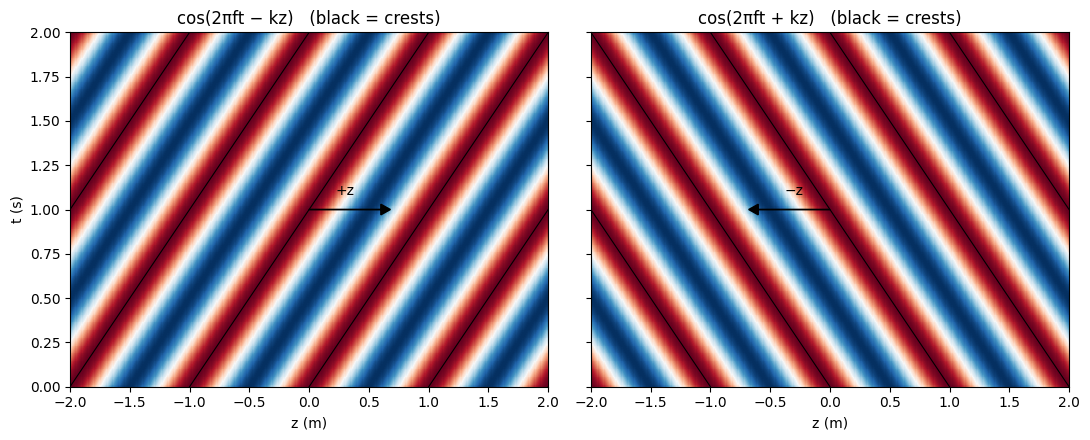

In [4]:
zz = np.linspace(-2, 2, 401); tt = np.linspace(0, 2, 401)
Z, T = np.meshgrid(zz, tt)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for a, (name, fn, sign) in zip(ax, [('cos(2πft − kz)', s_plus, +1), ('cos(2πft + kz)', s_minus, -1)]):
    a.pcolormesh(zz, tt, fn(Z, T), cmap='RdBu_r', shading='auto', vmin=-1, vmax=1)
    for m in range(-3, 4):                                   # crests: 2πft ∓ kz = 2πm  ->  z = ±(c t − mλ)
        a.plot(sign*(c*tt - m*lam), tt, 'k-', lw=0.8)
    a.set_xlim(zz.min(), zz.max()); a.set_ylim(tt.min(), tt.max())
    a.set_xlabel('z (m)'); a.set_title(name + '   (black = crests)')
    a.arrow(0, 1.0, sign*0.6, 0, head_width=0.06, head_length=0.08, fc='k', ec='k'); a.text(sign*0.3, 1.08, f'{"+z" if sign>0 else "−z"}', ha='center')
ax[0].set_ylabel('t (s)'); plt.tight_layout(); plt.show()

Left: crests lean to the right — as $t$ increases (going up), $z$ increases. Right: they lean to the left. The slope $dz/dt$ of each stripe is $+c$ on the left and $-c$ on the right, exactly the result of section 2.

## 4. Lag and lead: the array's point of view

The array does not watch crests move; it samples the wave at fixed points and compares their **phases** at one instant. Take the $+z$ wave and two points $z_1 < z_2$. At time $t$ their phases are

$$ \Phi(z_1) = 2\pi f t - k z_1, \qquad \Phi(z_2) = 2\pi f t - k z_2, \qquad \Phi(z_2) - \Phi(z_1) = -k\,(z_2 - z_1) < 0 $$

The point farther along the direction of travel has the *smaller* phase: it **lags**. Physically, the wave reaches $z_2$ later, so at any instant $z_2$ is displaying an earlier part of the waveform than $z_1$. A point the wave reaches first **leads** (larger phase).

For the $-z$ wave the sign flips: $\Phi(z_2) - \Phi(z_1) = +k(z_2 - z_1)$, and now $z_2$ leads because the wave reaches it first.

So the sign of the phase difference between two fixed points tells the direction of travel, using a single instant of time — this is what an antenna array measures.

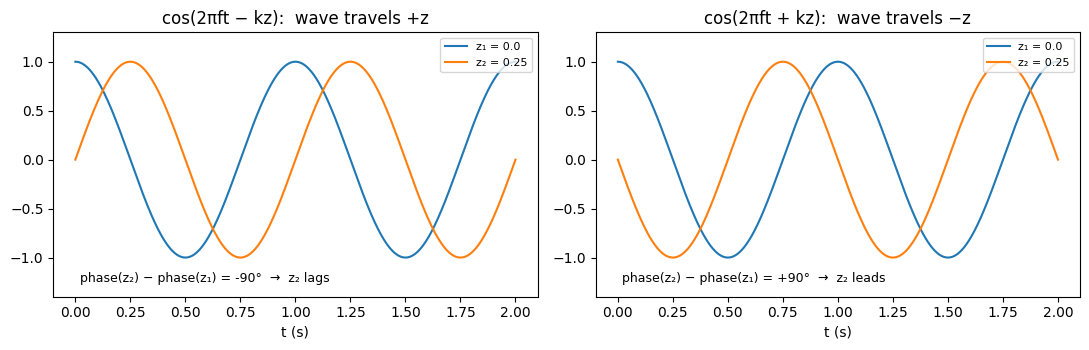

In [5]:
z1, z2 = 0.0, 0.25          # a quarter wavelength apart
t = np.linspace(0, 2, 801)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for a, (name, fn) in zip(ax, [('cos(2πft − kz):  wave travels +z', s_plus), ('cos(2πft + kz):  wave travels −z', s_minus)]):
    a.plot(t, fn(z1, t), label=f'z₁ = {z1}')
    a.plot(t, fn(z2, t), label=f'z₂ = {z2}')
    a.set_xlabel('t (s)'); a.set_title(name); a.legend(loc='upper right', fontsize=8)
    dphi = np.degrees(-k*(z2-z1)) if fn is s_plus else np.degrees(k*(z2-z1))
    a.text(0.02, -1.25, f'phase(z₂) − phase(z₁) = {dphi:+.0f}°  →  z₂ {"lags" if dphi<0 else "leads"}', fontsize=9)
    a.set_ylim(-1.4, 1.3)
plt.tight_layout(); plt.show()

Left: the $z_2$ trace reaches its crest a quarter period *after* $z_1$ (it lags by 90°). Right: a quarter period *before* (it leads by 90°). Same two points, same instant of sampling — opposite conclusions about direction.

## 5. Phasor form

Write the cosine as the real part of a complex exponential and separate time from space:

$$ \cos(2\pi f t \mp k z) = \operatorname{Re}\left\{ e^{\,j(2\pi f t \mp k z)} \right\} = \operatorname{Re}\left\{ e^{\,\mp j k z}\; e^{\,j 2\pi f t} \right\} $$

The time factor $e^{j2\pi ft}$ is the same at every point, so once it is removed (which is what the mixer in Step 1 does) each point is represented by its **spatial phasor**

$$ s_+(z) = e^{-jkz} \quad (\text{travels } +z), \qquad s_-(z) = e^{+jkz} \quad (\text{travels } -z) $$

The phasor of a point farther along the travel direction is rotated *clockwise* (negative angle) relative to a point behind it: lag = clockwise. Plot the phasors at four points a quarter wavelength apart:

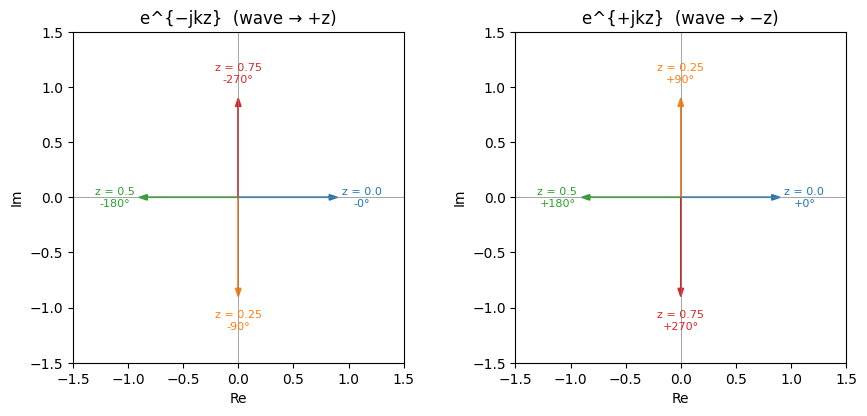

In [6]:
pts = np.array([0, 0.25, 0.5, 0.75])
fig, ax = plt.subplots(1, 2, figsize=(9, 4.2))
for a, (name, sgn) in zip(ax, [('e^{−jkz}  (wave → +z)', -1), ('e^{+jkz}  (wave → −z)', +1)]):
    for i, zp in enumerate(pts):
        ph = np.exp(1j*sgn*k*zp)
        a.arrow(0, 0, 0.9*ph.real, 0.9*ph.imag, head_width=0.05, length_includes_head=True, color=f'C{i}')
        a.text(1.12*ph.real, 1.12*ph.imag, f'z = {zp}\n{np.degrees(sgn*k*zp):+.0f}°', ha='center', va='center', fontsize=8, color=f'C{i}')
    a.set_aspect('equal'); a.set_xlim(-1.5, 1.5); a.set_ylim(-1.5, 1.5); a.set_title(name)
    a.axhline(0, color='gray', lw=0.5); a.axvline(0, color='gray', lw=0.5); a.set_xlabel('Re'); a.set_ylabel('Im')
plt.tight_layout(); plt.show()

Going along the direction of travel, the phasor turns clockwise by $k\,\Delta z$ per step in both cases — because in both cases the farther point lags. What differs is which way "along the direction of travel" is in $z$.

## 6. Connection to the steering vector

For a wave in an arbitrary direction $\hat{\mathbf k}$, replace $z$ by the projection $\hat{\mathbf k}\cdot\mathbf r$: the spatial phasor is $e^{-j\mathbf k\cdot\mathbf r}$ with $\mathbf k = k\hat{\mathbf k}$. The array describes the source by the *arrival* direction $\hat{\mathbf s} = -\hat{\mathbf k}$ (the direction you look to see the tag), so the phasor at antenna $n$ becomes

$$ e^{-j\mathbf k\cdot\mathbf r_n} = e^{+j\frac{2\pi}{\lambda}\hat{\mathbf s}\cdot\mathbf r_n} = e^{\,j\psi_n} $$

An antenna displaced toward the source is reached first and leads — positive $\psi_n$. That is the steering vector $a_n = e^{j\psi_n}$ of Step 3, and the sign in front of $kz$ in this notebook is where its sign comes from.